# RRZ - kontrola kroku czasowego w problemach sztywnych.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

Constants

In [2]:
dbl = lambda d: np.double(d)
nparr = lambda *args: np.array(args, dtype=np.double)
x0 = dbl(0.01)
V0 = dbl(0)
dt0 = dbl(1)
S = dbl(0.75)
p = dbl(2)
tmax = dbl(40)
ALPHA = dbl(5)
TOL = nparr(1e-2, 1e-5)

In [3]:
def NumericalAlgorithm(diagram, file, tol):
    dt = dt0
    t = dbl(0)
    xn = x0
    vn = V0
    at = nparr()
    adt = nparr()
    axn = nparr()
    avn = nparr()
    while t < tmax:
        x2n1, v2n1 = diagram(xn, vn, dt, ALPHA)
        x2n2, v2n2 = diagram(x2n1, v2n1, dt, ALPHA)

        x1n2, v1n2 = diagram(xn, vn, 2 * dt, ALPHA)

        Ex = (x2n2 - x1n2) / (np.power(2, p) - 1)
        Ev = (v2n2 - v1n2) / (np.power(2, p) - 1)

        m = np.max(np.abs([Ex, Ev]))
        if m < tol:
            t += 2 * dt
            xn = x2n2
            vn = v2n2
            at = np.append(at, t)
            adt = np.append(adt, dt)
            axn = np.append(axn, xn)
            avn = np.append(avn, vn)
            file.write(f"{t}\t{dt}\t{xn}\t{vn}\n")
        
        dt = np.power(S * tol / m, 1 / (p + 1)) * dt
    return at, adt, axn, avn

- Schemat Numeryczny: Kontrola Trapezów

In [4]:
RO = dbl(1e-10)
def TrapezoidalDiagram(xn, vn, dt, alp):
    xn1 = xn
    vn1 = vn
    while True:
        a11 = 1
        a12 = -dt / 2
        a21 = -dt / 2 * (- 2 * alp * xn1 * vn1 - 1)
        a22 = 1 - dt / 2 * alp * (1 - np.power(xn1, 2))

        F = xn1 - xn - dt / 2 * (vn1 + vn)
        G = vn1 - vn - dt / 2 * ((alp * (1 - xn * xn) * vn - xn) + (alp * (1 - xn1 * xn1) * vn1 - xn1))

        dx = (-F * a22 + G * a12) / (a11 * a22 - a12 * a21)
        dv = (-G * a11 + F * a21) / (a11 * a22 - a12 * a21)

        xn1 += dx
        vn1 += dv
        if np.all(np.abs([dx, dv]) < RO):
            break
    return xn1, vn1

gtt1 = gtdt1 = gtxn1 = gtvn1 = None
gtt2 = gtdt2 = gtxn2 = gtvn2 = None
with open("mTrapezoidal.txt", "w") as trapf:
    trapf.write("TOL=10^-2\n")
    gtt1, gtdt1, gtxn1, gtvn1 = NumericalAlgorithm(TrapezoidalDiagram, trapf, TOL[0])
    trapf.write("\nTOL=10^-6\n")
    gtt2, gtdt2, gtxn2, gtvn2 = NumericalAlgorithm(TrapezoidalDiagram, trapf, TOL[1])

- Schemat Numeryczny: metoda KR2

In [5]:
def KR2Diagram(xn, vn, dt, alp):
    k1x = vn
    k1v = alp * (1 - xn * xn) * vn - xn

    k2x = vn + dt * k1v
    k2v = alp * (1 - np.power(xn + dt * k1x, 2)) * (vn + dt * k1v) - (xn + dt * k1x)

    xn += dt / 2 * (k1x + k2x)
    vn += dt / 2 * (k1v + k2v)

    return xn, vn

gkt1 = gkdt1 = gkxn1 = gkvn1 = None
gkt2 = gkdt2 = gkxn2 = gkvn2 = None
with open("mKR2.txt", "w") as kr2f:
    kr2f.write("TOL=10^-2\n")
    gkt1, gkdt1, gkxn1, gkvn1 = NumericalAlgorithm(KR2Diagram, kr2f, TOL[0])
    kr2f.write("\nTOL=10^-6\n")
    gkt2, gkdt2, gkxn2, gkvn2 = NumericalAlgorithm(KR2Diagram, kr2f, TOL[1])

# Wykresy

In [6]:
def plot(t, dt, legend):
    legend_handles = [
        Line2D([0], [0], color=legend[1][0], lw=2, label=f'TOL={TOL[0]}'),
        Line2D([0], [0], color=legend[1][1], lw=2, label=f'TOL={TOL[1]}'),
    ]
    
    plt.plot(t[0], dt[0], color=legend[1][0])
    plt.plot(t[1], dt[1], color=legend[1][1])

    plt.legend(loc="upper right", handles=legend_handles)
    plt.xlabel(legend[2][0])
    plt.ylabel(legend[2][1])
    plt.title(legend[0])

    plt.show()

- Metoda Trapezów

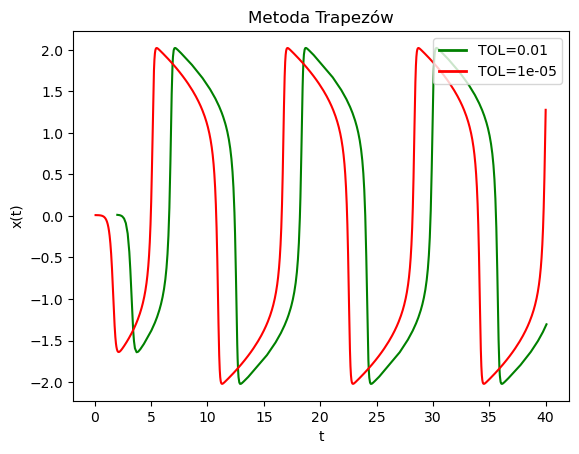

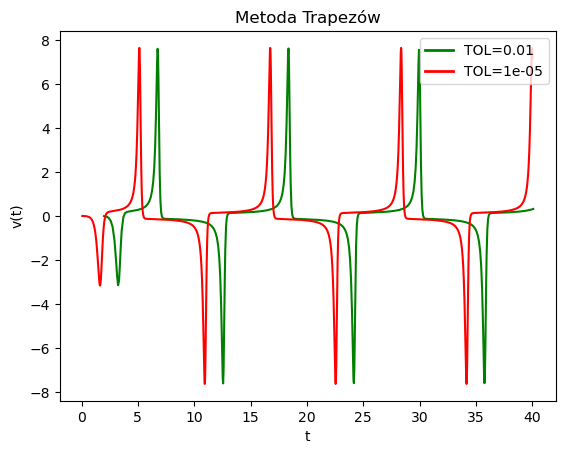

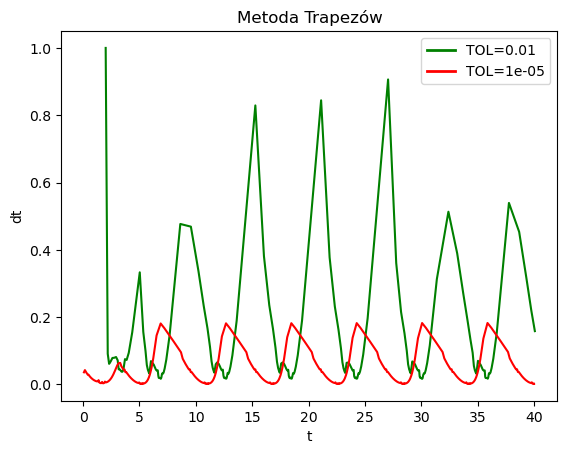

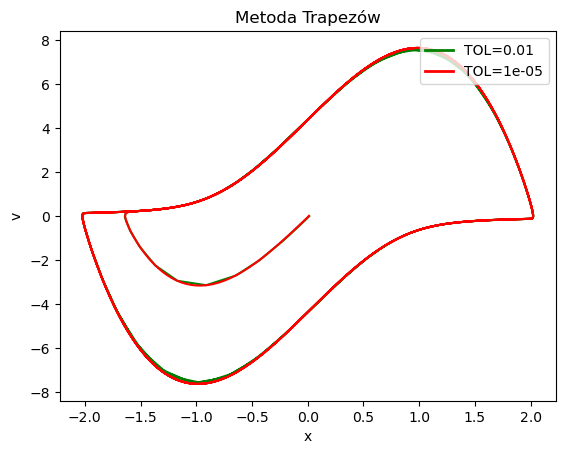

In [7]:
TrapezoidalLegend = ("Metoda Trapezów", ("green", "red"), ("t", "x(t)"))
plot((gtt1, gtt2), (gtxn1, gtxn2), TrapezoidalLegend)
TrapezoidalLegend = ("Metoda Trapezów", ("green", "red"), ("t", "v(t)"))
plot((gtt1, gtt2), (gtvn1, gtvn2), TrapezoidalLegend)
TrapezoidalLegend = ("Metoda Trapezów", ("green", "red"), ("t", "dt"))
plot((gtt1, gtt2), (gtdt1, gtdt2), TrapezoidalLegend)
TrapezoidalLegend = ("Metoda Trapezów", ("green", "red"), ("x", "v"))
plot((gtxn1, gtxn2), (gtvn1, gtvn2), TrapezoidalLegend)

- Metoda KR2

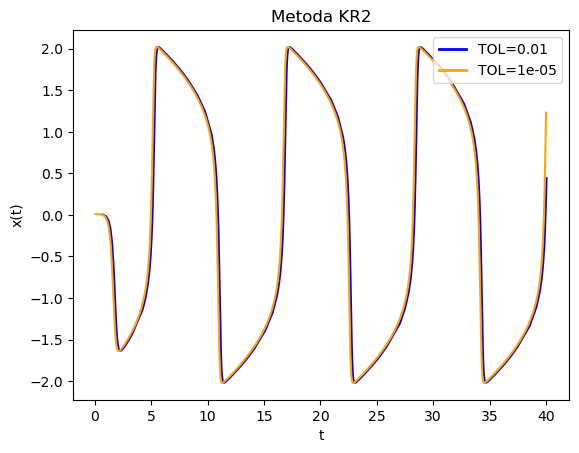

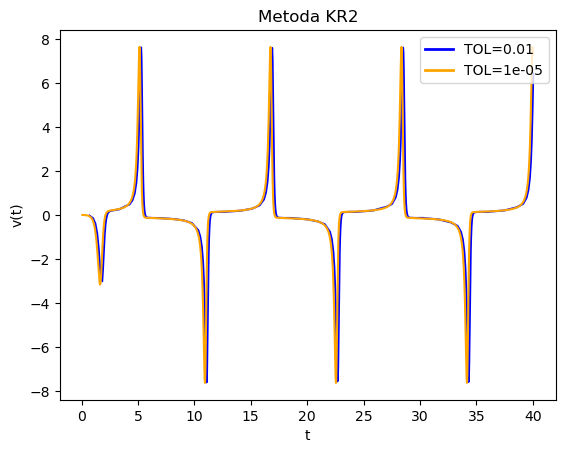

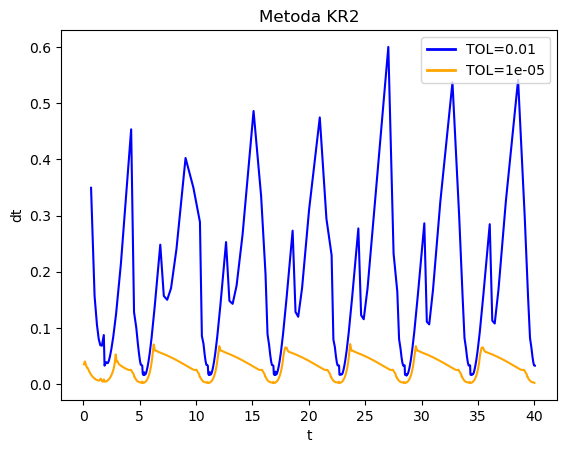

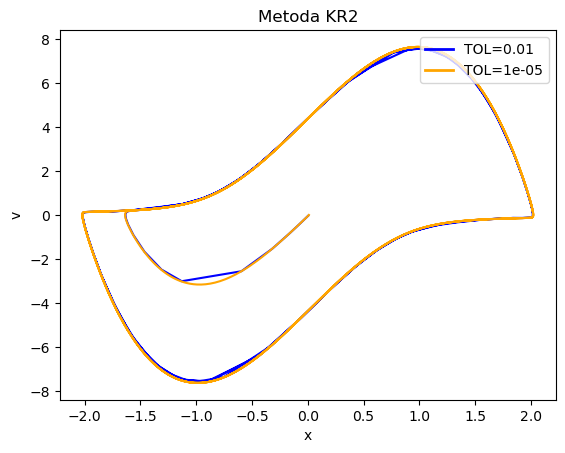

In [8]:
KR2Legend = ("Metoda KR2", ("blue", "orange"), ("t", "x(t)"))
plot((gkt1, gkt2), (gkxn1, gkxn2), KR2Legend)
KR2Legend = ("Metoda KR2", ("blue", "orange"), ("t", "v(t)"))
plot((gkt1, gkt2), (gkvn1, gkvn2), KR2Legend)
KR2Legend = ("Metoda KR2", ("blue", "orange"), ("t", "dt"))
plot((gkt1, gkt2), (gkdt1, gkdt2), KR2Legend)
KR2Legend = ("Metoda KR2", ("blue", "orange"), ("x", "v"))
plot((gkxn1, gkxn2), (gkvn1, gkvn2), KR2Legend)